In [40]:
import numpy as np
import sys
import os

sys.path.append('..')

from rl.reward import compute_reward
from rl.state_builder import STATE_COLUMNS
from rl.action_space import ACTION_TO_INDEX

## 1. Reward Scenarios

In [43]:
def test_reward(description, prev_mods, next_mods, action_name):
    s_prev = np.zeros(len(STATE_COLUMNS))
    s_next = np.zeros(len(STATE_COLUMNS))
    
    for idx, val in prev_mods.items():
        s_prev[idx] = val
    for idx, val in next_mods.items():
        s_next[idx] = val
        
    action_id = ACTION_TO_INDEX[action_name]
    r = compute_reward(s_prev, action_id, s_next)
    print(f"{description:<40} | Action: {action_name:<15} | Reward: {r}")
    return r

print(f"{'Scenario':<40} | {'Action':<15} | {'Reward'}")
print("-" * 70)
test_reward("Base Step Penalty", {}, {}, "route_bug")
test_reward("Resolution Success (+10 + 5 - 1)", {}, {30: 1.0}, "suggest_top1")
test_reward("SLA Breach (-10 - 1)", {5: 0.0}, {5: 1.0}, "route_bug")
test_reward("Frustration Increase (-4 - 1)", {27: 0.2}, {27: 0.5}, "ask_version")
test_reward("Unnecessary Clarification (-2 - 1)", {23: 0.0}, {}, "ask_version")
test_reward("Gap Suggestion (-2 - 1)", {34: 1.0}, {}, "suggest_top1")
test_reward("Unnecessary Escalation (-6 - 1)", {27: 0.1}, {}, "escalate_human")

None

Scenario                                 | Action          | Reward
----------------------------------------------------------------------
Base Step Penalty                        | Action: route_bug       | Reward: -1.0
Resolution Success (+10 + 5 - 1)         | Action: suggest_top1    | Reward: 15.0
SLA Breach (-10 - 1)                     | Action: route_bug       | Reward: -11.0
Frustration Increase (-4 - 1)            | Action: ask_version     | Reward: -4.2
Unnecessary Clarification (-2 - 1)       | Action: ask_version     | Reward: -3.0
Gap Suggestion (-2 - 1)                  | Action: suggest_top1    | Reward: -5.0
Unnecessary Escalation (-6 - 1)          | Action: escalate_human  | Reward: -7.0


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rl.environment import NexResolveEnv
from rl.reward import compute_reward
from rl.action_masking import get_action_mask

In [45]:
env = NexResolveEnv("../data/final/rl_ready_dataset.csv")

rewards = []
success_flags = []
actions_taken = []

In [47]:
num_episodes = 500

for _ in range(num_episodes):
    state = env.reset()

    done = False
    step_count = 0

    while not done and step_count < 6:
        mask = get_action_mask(state)
        valid_actions = np.where(mask == 1)[0]

        if len(valid_actions) == 0:
            break

        action = np.random.choice(valid_actions)

        next_state, _, done, _ = env.step(action)

        r = compute_reward(state, action, next_state)

        rewards.append(r)
        success_flags.append(next_state[30])  # resolution_success
        actions_taken.append(action)

        state = next_state
        step_count += 1

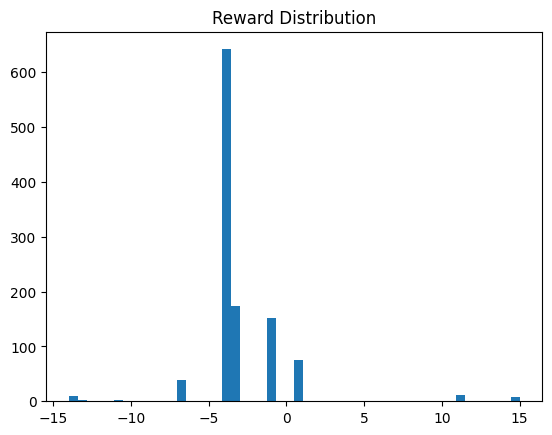

In [48]:
plt.hist(rewards, bins=50)
plt.title("Reward Distribution")
plt.show()

analysis_df = pd.DataFrame({
    "reward": rewards,
    "resolution_success": success_flags
})

In [49]:
print(analysis_df.groupby("resolution_success")["reward"].mean())

resolution_success
0.0   -3.676271
1.0   -1.477228
Name: reward, dtype: float64


In [50]:
print("Max reward:",np.max(rewards))
print("Min reward:",np.min(rewards))

Max reward: 15.0
Min reward: -14.0
